# 1. Data Exploration:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('diabetes.csv')

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.shape

(768, 9)

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
num_data=data._get_numeric_data()
num_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


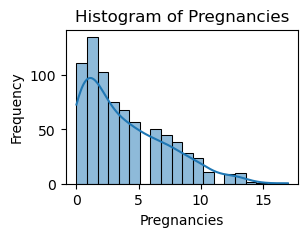

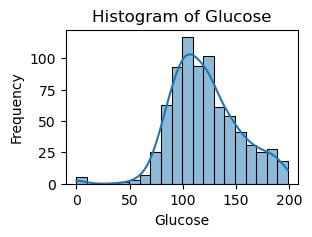

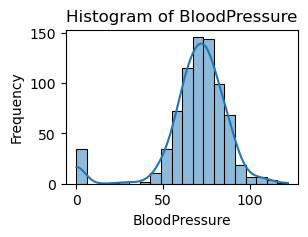

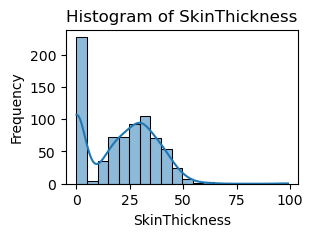

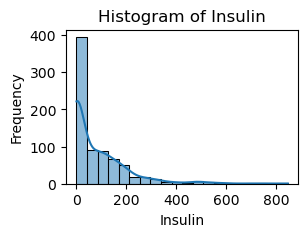

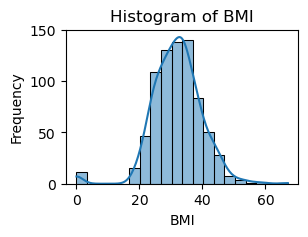

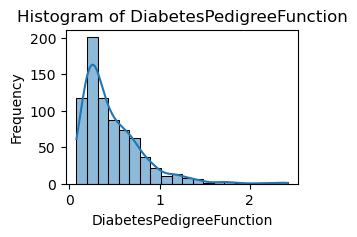

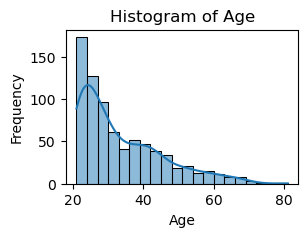

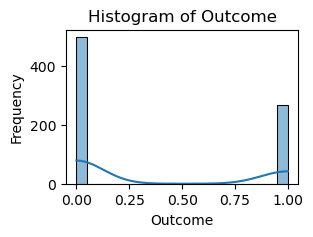

In [8]:
for col in num_data:
    plt.figure(figsize=(3,2))
    sns.histplot(data[col],kde=True,bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

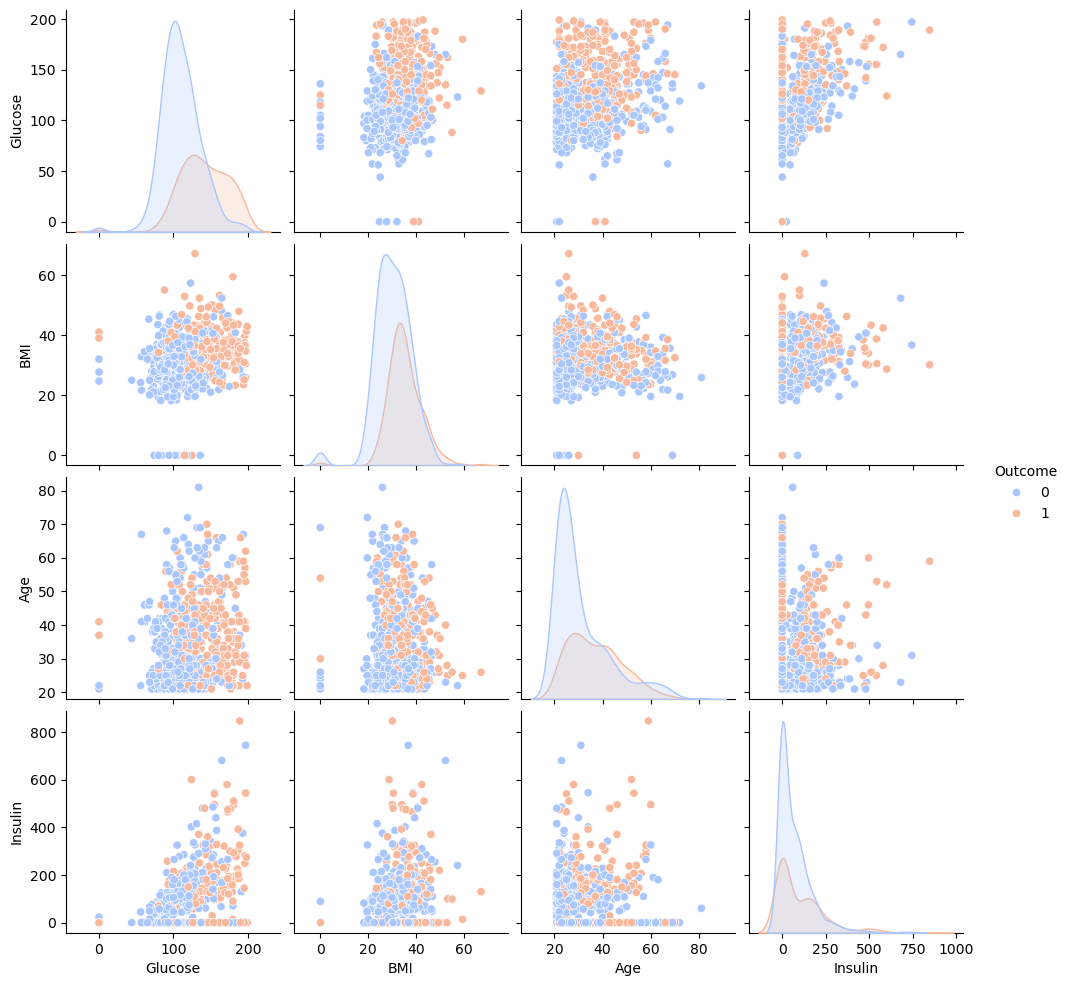

In [9]:
important_cols=['Glucose','BMI','Age','Insulin','Outcome']
sns.pairplot(
    data=data[important_cols],
    hue='Outcome',      
    diag_kind='kde',    
    palette='coolwarm'
)
plt.show()

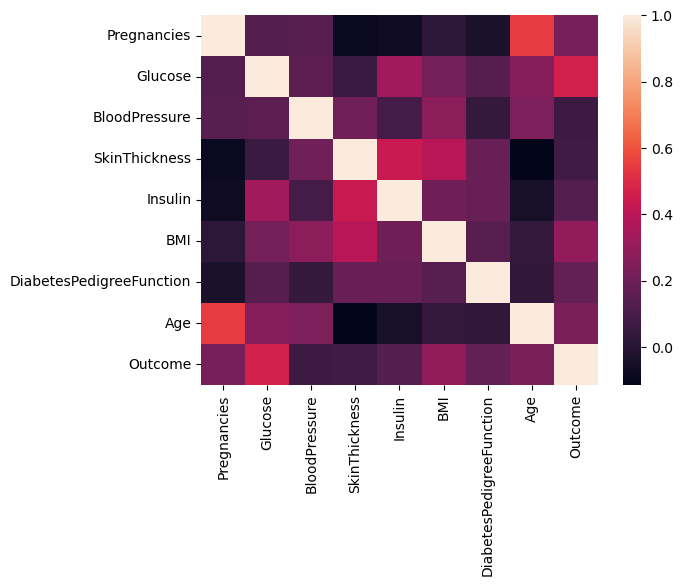

In [10]:
num_corr=data.corr()
sns.heatmap(num_corr)
plt.show()

# 2. Data Preprocessing:

In [11]:
df_cleaned=data.copy()

In [12]:
df_cleaned.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df_cleaned.drop_duplicates(inplace=True)

In [14]:
df_cleaned.shape

(768, 9)

In [15]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 3. Model Building:

In [16]:
X=df_cleaned.drop("Outcome", axis=1)
y= df_cleaned["Outcome"]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [19]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [20]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score, recall_score, f1_score,roc_curve

In [21]:
yhat_train =model.predict(X_train)
y_prob = model.predict_proba(X_train)[:,1]

In [22]:
print("Model_Training_metrics")
print("accuracy:", accuracy_score(y_train, yhat_train))
print("precision:",precision_score(y_train, yhat_train))
print("recall:",recall_score(y_train, yhat_train))
print("f1:",f1_score(y_train, yhat_train))
print("ROC-AUC:", roc_auc_score(y_train, yhat_train))

Model_Training_metrics
accuracy: 0.7703583061889251
precision: 0.7168674698795181
recall: 0.5586854460093896
f1: 0.6279683377308707
ROC-AUC: 0.7207392317328744


# 4. Model Evaluation:

In [23]:
yhat_test =model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [24]:
def evaluate_model(y_true, y_pred, y_prob):    
    # Classification metrics
    print("accuracy:", accuracy_score(y_test, yhat_test))
    print("precision:",precision_score(y_test, yhat_test))
    print("recall:",recall_score(y_test, yhat_test))
    print("f1:",f1_score(y_test, yhat_test))
    print("ROC-AUC:", roc_auc_score(y_test, yhat_test))
        # ROC metrics
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)    
    # Plot ROC curve
    plt.figure(figsize=(5,5))
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], '--')
    plt.legend()
    plt.show()

accuracy: 0.7532467532467533
precision: 0.6491228070175439
recall: 0.6727272727272727
f1: 0.6607142857142857
ROC-AUC: 0.7353535353535354


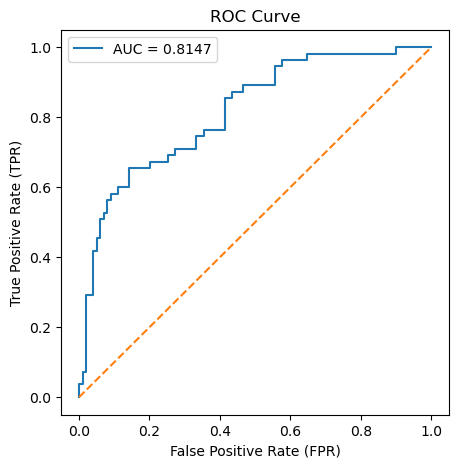

In [25]:
evaluate_model(y_test,yhat_test,y_prob)

# 5. Interpretation:

In [26]:
model.coef_

array([[ 0.21255394,  1.07130143, -0.24782647,  0.0457288 , -0.20078252,
         0.77818216,  0.23062467,  0.42120732]])

In [27]:
model_params = pd.DataFrame(model.coef_.T, index=X.columns, columns=['LogisticReg'])
model_params

,LogisticReg
Pregnancies,0.212554
Glucose,1.071301
BloodPressure,-0.247826
SkinThickness,0.045729
Insulin,-0.200783
BMI,0.778182
DiabetesPedigreeFunction,0.230625
Age,0.421207


In [28]:
df_cleaned.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [29]:
from scipy.stats import pearsonr
selected_feature=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

correlation={
    feature:pearsonr(df_cleaned[feature],df_cleaned['Outcome'])[0]
    for feature in selected_feature
}
correlation_df=pd.DataFrame(list(correlation.items()),columns=['selected_feature', 'pearsonr_corr'])
correlation_df=correlation_df.sort_values(by='pearsonr_corr', ascending=False)
print("Significant feature in predicting target variable")
correlation_df

Significant feature in predicting target variable


,selected_feature,pearsonr_corr
8,Outcome,1.000000
1,Glucose,0.466581
5,BMI,0.292695
7,Age,0.238356
0,Pregnancies,0.221898
6,DiabetesPedigreeFunction,0.173844
4,Insulin,0.130548
3,SkinThickness,0.074752
2,BloodPressure,0.065068


# 6. Deployment with Streamlit:

In [30]:
yhat_test

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [33]:
from pickle import dump

In [34]:
dump(model,open('clf.pkl','wb'))